## Cell 1 — Install dependencies (run once)

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision opencv-python h5py numpy numba editdistance matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Cell 2 — Imports

In [2]:
from pathlib import Path
import numpy as np
import math
from itertools import groupby
import h5py
import numpy as np
import unicodedata
import cv2
import torch
from torch import nn
from torchvision.models import resnet101
from torch.autograd import Variable
import torchvision
from torch.utils.data import Dataset
import time
import os
import datetime
import string
import re
import html
import editdistance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")
print("PyTorch version:", torch.__version__)
print("Device: CPU (no CUDA required)")

Imports OK
PyTorch version: 2.10.0
Device: CPU (no CUDA required)


## Cell 3 — Preprocessing utilities  


In [3]:

def adjust_to_see(img):
    """Rotate and transpose to image visualize"""
    (h, w) = img.shape[:2]
    (cX, cY) = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D((cX, cY), -90, 1.0)
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))
    M[0, 2] += (nW / 2) - cX
    M[1, 2] += (nH / 2) - cY
    img = cv2.warpAffine(img, M, (nW + 1, nH + 1))
    img = cv2.warpAffine(img.transpose(), M, (nW, nH))
    return img


def normalization(img):
    m, s = cv2.meanStdDev(img)
    img = img - m[0][0]
    img = img / s[0][0] if s[0][0] > 0 else img
    return img



RE_DASH_FILTER = re.compile(r'[\-\˗\֊\‐\‑\‒\–\—\⁻\₋\−\﹣\－]', re.UNICODE)
RE_APOSTROPHE_FILTER = re.compile(
    r'&#39;|[ʼ՚＇\u2018\u2019\u201b\u2039\u203a\u02bc\u02cb\u02ca\u02b9\u02bb`\u2035\u00b4\u02ca\u02cb]',
    re.UNICODE)
RE_RESERVED_CHAR_FILTER = re.compile(r'[¶¤«»]', re.UNICODE)
RE_LEFT_PARENTH_FILTER  = re.compile(r'[\(\[\{\⁽\₍\❨\❪\﹙\（]', re.UNICODE)
RE_RIGHT_PARENTH_FILTER = re.compile(r'[\)\]\}\⁾\₎\❩\❫\﹚\）]', re.UNICODE)
RE_BASIC_CLEANER        = re.compile(r'[^\w\s{}]'.format(re.escape(string.punctuation)), re.UNICODE)
LEFT_PUNCTUATION_FILTER  = """!%&),.:;<=>?@\\]^_`|}~"""
RIGHT_PUNCTUATION_FILTER = """\"(/<=>@[\\^_`{|~"""
NORMALIZE_WHITESPACE_REGEX = re.compile(r'[^\S\n]+', re.UNICODE)


def text_standardize(text):
    """Organize/add spaces around punctuation marks"""
    if text is None:
        return ""
    text = html.unescape(text).replace("\\n", "").replace("\\t", "")
    text = RE_RESERVED_CHAR_FILTER.sub("", text)
    text = RE_DASH_FILTER.sub("-", text)
    text = RE_APOSTROPHE_FILTER.sub("'", text)
    text = RE_LEFT_PARENTH_FILTER.sub("(", text)
    text = RE_RIGHT_PARENTH_FILTER.sub(")", text)
    text = RE_BASIC_CLEANER.sub("", text)
    text = text.lstrip(LEFT_PUNCTUATION_FILTER)
    text = text.rstrip(RIGHT_PUNCTUATION_FILTER)
    text = text.translate(str.maketrans({c: f" {c} " for c in string.punctuation}))
    text = NORMALIZE_WHITESPACE_REGEX.sub(" ", text.strip())
    return text


print("Preprocessing utilities loaded.")

Preprocessing utilities loaded.


## Cell 4 — Evaluation utilities  


In [4]:


def ocr_metrics(predicts, ground_truth, norm_accentuation=False, norm_punctuation=False):
    """Calculate CER, WER and SER"""
    if len(predicts) == 0 or len(ground_truth) == 0:
        return (1, 1, 1)

    cer, wer, ser = [], [], []

    for (pd, gt) in zip(predicts, ground_truth):
        pd, gt = pd.lower(), gt.lower()

        if norm_accentuation:
            pd = unicodedata.normalize("NFKD", pd).encode("ASCII", "ignore").decode("ASCII")
            gt = unicodedata.normalize("NFKD", gt).encode("ASCII", "ignore").decode("ASCII")

        if norm_punctuation:
            pd = pd.translate(str.maketrans("", "", string.punctuation))
            gt = gt.translate(str.maketrans("", "", string.punctuation))

        pd_cer, gt_cer = list(pd), list(gt)
        dist = editdistance.eval(pd_cer, gt_cer)
        cer.append(dist / (max(len(pd_cer), len(gt_cer))))

        pd_wer, gt_wer = pd.split(), gt.split()
        dist = editdistance.eval(pd_wer, gt_wer)
        wer.append(dist / (max(len(pd_wer), len(gt_wer))))

        pd_ser, gt_ser = [pd], [gt]
        dist = editdistance.eval(pd_ser, gt_ser)
        ser.append(dist / (max(len(pd_ser), len(gt_ser))))

    metrics = [cer, wer, ser]
    metrics = np.mean(metrics, axis=1)
    return metrics


print("Evaluation utilities loaded.")

Evaluation utilities loaded.


## Cell 5 — Model definition  


In [5]:


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=128):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)


class OCR(nn.Module):

    def __init__(self, vocab_len, hidden_dim, nheads,
                 num_encoder_layers, num_decoder_layers):
        super().__init__()

        # ResNet-101 backbone
        self.backbone = resnet101()
        del self.backbone.fc

        self.conv = nn.Conv2d(2048, hidden_dim, 1)

        self.transformer = nn.Transformer(
            hidden_dim, nheads, num_encoder_layers, num_decoder_layers)

        self.vocab = nn.Linear(hidden_dim, vocab_len)

        # output positional encodings 
        self.decoder = nn.Embedding(vocab_len, hidden_dim)
        self.query_pos = PositionalEncoding(hidden_dim, .2)

        # spatial positional encodings
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
        self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
        self.trg_mask = None

    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz), 1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def get_feature(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        return x

    def make_len_mask(self, inp):
        return (inp == 0).transpose(0, 1)

    def forward(self, inputs, trg):
  
        x = self.get_feature(inputs)


        h = self.conv(x)

    
        bs, _, H, W = h.shape
        pos = torch.cat([
            self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),
            self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),
        ], dim=-1).flatten(0, 1).unsqueeze(1)


        if self.trg_mask is None or self.trg_mask.size(0) != len(trg):
            self.trg_mask = self.generate_square_subsequent_mask(trg.shape[1]).to(trg.device)

        trg_pad_mask = self.make_len_mask(trg)

        
        trg = self.decoder(trg)
        trg = self.query_pos(trg)

        output = self.transformer(
            pos + 0.1 * h.flatten(2).permute(2, 0, 1),
            trg.permute(1, 0, 2),
            tgt_mask=self.trg_mask,
            tgt_key_padding_mask=trg_pad_mask.permute(1, 0)
        )

        return self.vocab(output.transpose(0, 1))


def make_model(vocab_len, hidden_dim=256, nheads=4,
               num_encoder_layers=4, num_decoder_layers=4):
    return OCR(vocab_len, hidden_dim, nheads,
               num_encoder_layers, num_decoder_layers)


print("Model definition loaded.")

Model definition loaded.


## Cell 6 — DataGenerator & Tokenizer  


In [6]:
class DataGenerator(Dataset):
    """Generator class with data streaming"""

    def __init__(self, source, charset, max_text_length, split, transform):
        self.tokenizer = Tokenizer(charset, max_text_length)
        self.transform = transform
        self.split = split
        self.dataset = dict()

        with h5py.File(source, "r") as f:
            self.dataset[self.split] = dict()
            self.dataset[self.split]['dt'] = np.array(f[self.split]['dt'])
            self.dataset[self.split]['gt'] = np.array(f[self.split]['gt'])

            randomize = np.arange(len(self.dataset[self.split]['gt']))
            np.random.seed(42)
            np.random.shuffle(randomize)

            self.dataset[self.split]['dt'] = self.dataset[self.split]['dt'][randomize]
            self.dataset[self.split]['gt'] = self.dataset[self.split]['gt'][randomize]

            # decode sentences from byte
            self.dataset[self.split]['gt'] = [x.decode() for x in self.dataset[self.split]['gt']]

        self.size = len(self.dataset[self.split]['gt'])

    def __getitem__(self, i):
        img = self.dataset[self.split]['dt'][i]

        # making image compatible with resnet
        img = np.repeat(img[..., np.newaxis], 3, -1)
        img = normalization(img)

        if self.transform is not None:
            img = self.transform(img)

        y_train = self.tokenizer.encode(self.dataset[self.split]['gt'][i])

        # padding till max length
        y_train = np.pad(y_train, (0, self.tokenizer.maxlen - len(y_train)))

        gt = torch.Tensor(y_train)
        return img, gt

    def __len__(self):
        return self.size


class Tokenizer():
    """Manager tokens functions and charset/dictionary properties"""

    def __init__(self, chars, max_text_length=128):
        self.PAD_TK, self.UNK_TK, self.SOS, self.EOS = "¶", "¤", "SOS", "EOS"
        self.chars = [self.PAD_TK] + [self.UNK_TK] + [self.SOS] + [self.EOS] + list(chars)
        self.PAD = self.chars.index(self.PAD_TK)
        self.UNK = self.chars.index(self.UNK_TK)
        self.vocab_size = len(self.chars)
        self.maxlen = max_text_length

    def encode(self, text):
        """Encode text to vector"""
        text = unicodedata.normalize("NFKD", text).encode("ASCII", "ignore").decode("ASCII")
        text = " ".join(text.split())

        groups = ["".join(group) for _, group in groupby(text)]
        text = "".join([self.UNK_TK.join(list(x)) if len(x) > 1 else x for x in groups])
        encoded = []

        text = ['SOS'] + list(text) + ['EOS']
        for item in text:
            index = self.chars.index(item) if item in self.chars else -1
            index = self.UNK if index == -1 else index
            encoded.append(index)

        return np.asarray(encoded)

    def decode(self, text):
        """Decode vector to text"""
        decoded = "".join([self.chars[int(x)] for x in text if x > -1])
        decoded = decoded.replace(self.PAD_TK, "").replace(self.UNK_TK, "")
        decoded = text_standardize(decoded)
        return decoded


print("DataGenerator & Tokenizer loaded.")

DataGenerator & Tokenizer loaded.


## Cell 7 — Config & paths



In [9]:
batch_size = 16
epochs = 200

source = 'bentham'

# UPDATE THIS PATH to point to where you placed the bentham.hdf5 file.
source_path = r'../data/bentham.hdf5'  
output_path = os.path.join('output', source)
target_path = os.path.join(output_path, 'checkpoint_weights.hdf5')

os.makedirs(output_path, exist_ok=True)
input_size = (1024, 128, 1)
max_text_length = 128
charset_base = string.printable[:95]

print("source:", source_path)
print("output:", output_path)
print("target:", target_path)
print("charset:", charset_base)

source: /Users/tejasjindal/Documents/htr_project/data/bentham.hdf5
output: output/bentham
target: output/bentham/checkpoint_weights.hdf5
charset: 0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~ 


## Cell 8 — Device & DataLoaders


In [10]:
import torchvision.transforms as T

device = torch.device("cpu")
print("Using device:", device)

transform = T.Compose([T.ToTensor()])
tokenizer = Tokenizer(charset_base)

train_loader = torch.utils.data.DataLoader(
    DataGenerator(source_path, charset_base, max_text_length, 'train', transform),
    batch_size=batch_size, shuffle=False, num_workers=0)

val_loader = torch.utils.data.DataLoader(
    DataGenerator(source_path, charset_base, max_text_length, 'valid', transform),
    batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Using device: cpu
Train batches: 529 | Val batches: 83


## Cell 9 — Build model and send to device

In [11]:
model = make_model(vocab_len=tokenizer.vocab_size)
_ = model.to(device)
print(f"Model built. Vocab size: {tokenizer.vocab_size}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Model built. Vocab size: 99
Trainable parameters: 54,664,611


## Cell 10 — LabelSmoothing loss  


In [12]:
class LabelSmoothing(nn.Module):
    "Implement label smoothing."
    def __init__(self, size, padding_idx=0, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, Variable(true_dist, requires_grad=False))


print("LabelSmoothing loss defined.")

LabelSmoothing loss defined.


## Cell 11 — Optimizer & scheduler

In [13]:
criterion = LabelSmoothing(size=tokenizer.vocab_size, padding_idx=0, smoothing=0.1)
criterion.to(device)

lr = 0.0001
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0004)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.95)

print("Optimizer and scheduler configured.")

Optimizer and scheduler configured.


## Cell 12 — Train & Evaluate functions  
(Identical to original, only `.to(device)` uses cpu)

In [14]:
def train(model, criterion, optimiser, scheduler, dataloader):
    model.train()
    total_loss = 0
    for batch, (imgs, labels_y,) in enumerate(dataloader):
        imgs = imgs.to(device)
        labels_y = labels_y.to(device)

        optimiser.zero_grad()
        output = model(imgs.float(), labels_y.long()[:, :-1])

        norm = (labels_y != 0).sum()
        loss = criterion(
            output.log_softmax(-1).contiguous().view(-1, tokenizer.vocab_size),
            labels_y[:, 1:].contiguous().view(-1).long()
        ) / norm

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.2)
        optimizer.step()
        total_loss += loss.item() * norm

    return total_loss / len(dataloader)


def evaluate(model, criterion, dataloader):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch, (imgs, labels_y,) in enumerate(dataloader):
            imgs = imgs.to(device)
            labels_y = labels_y.to(device)

            output = model(imgs.float(), labels_y.long()[:, :-1])

            norm = (labels_y != 0).sum()
            loss = criterion(
                output.log_softmax(-1).contiguous().view(-1, tokenizer.vocab_size),
                labels_y[:, 1:].contiguous().view(-1).long()
            ) / norm

            epoch_loss += loss.item() * norm

    return epoch_loss / len(dataloader)


print("Train and evaluate functions defined.")

Train and evaluate functions defined.


## Cell 13 — Training loop  


In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs


best_valid_loss = np.inf
c = 0

for epoch in range(epochs):
    print(f'Epoch: {epoch+1:02}', 'learning rate{}'.format(scheduler.get_last_lr()))

    start_time = time.time()

    train_loss = train(model, criterion, optimizer, scheduler, train_loader)
    valid_loss = evaluate(model, criterion, val_loader)

    epoch_mins, epoch_secs = epoch_time(start_time, time.time())

    c += 1
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), target_path)
        c = 0

    if c > 4:
        # decrease lr if loss does not decrease after 5 steps
        scheduler.step()
        c = 0

    print(f'Time: {epoch_mins}m {epoch_secs}s')
    print(f'Train Loss: {train_loss:.3f}')
    print(f'Val   Loss: {valid_loss:.3f}')

In [15]:
# UPDATE THIS PATH to point to where you placed the model weights.
weights_path = r'../models/kllloss_resnet101.pt'  
model = make_model(vocab_len=100)
_ = model.to(device)

model.load_state_dict(torch.load(weights_path, map_location=device))
print("Weights loaded successfully.")

Weights loaded successfully.


## Cell 15 — Encoder memory helper & test (inference) function  


In [16]:
def get_memory(model, imgs):
    x = model.conv(model.get_feature(imgs))
    bs, _, H, W = x.shape
    pos = torch.cat([
        model.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),
        model.row_embed[:H].unsqueeze(1).repeat(1, W, 1),
    ], dim=-1).flatten(0, 1).unsqueeze(1)
    return model.transformer.encoder(pos + 0.1 * x.flatten(2).permute(2, 0, 1))


def test(model, test_loader, max_text_length):
    model.eval()
    predicts = []
    gt = []
    imgs = []
    with torch.no_grad():
        for batch in test_loader:
            src, trg = batch
            imgs.append(src.flatten(0, 1))
            src, trg = src.to(device), trg.to(device)
            memory = get_memory(model, src.float())
            out_indexes = [tokenizer.chars.index('SOS'), ]
            for i in range(max_text_length):
                mask = model.generate_square_subsequent_mask(i + 1).to(device)
                trg_tensor = torch.LongTensor(out_indexes).unsqueeze(1).to(device)
                output = model.vocab(
                    model.transformer.decoder(
                        model.query_pos(model.decoder(trg_tensor)),
                        memory,
                        tgt_mask=mask
                    )
                )
                out_token = output.argmax(2)[-1].item()
                out_indexes.append(out_token)
                if out_token == tokenizer.chars.index('EOS'):
                    break
            predicts.append(tokenizer.decode(out_indexes))
            gt.append(tokenizer.decode(trg.flatten(0, 1)))
    return predicts, gt, imgs


print("Inference helpers defined.")

Inference helpers defined.


## Cell 16 — Run inference on test set



In [17]:
test_loader = torch.utils.data.DataLoader(
    DataGenerator(source_path, charset_base, max_text_length, 'test', transform),
    batch_size=1, shuffle=False, num_workers=0)

predicts, gt, imgs = test(model, test_loader, max_text_length)

predicts = list(map(lambda x: x.replace('SOS', '').replace('EOS', ''), predicts))
gt       = list(map(lambda x: x.replace('SOS', '').replace('EOS', ''), gt))

print(f"Inference done on {len(predicts)} samples.")

Inference done on 796 samples.


## Cell 17 — CER / WER / SER evaluation

In [18]:
evaluate_result = ocr_metrics(predicts=predicts, ground_truth=gt)

print("Calculate Character Error Rate {:.4f}, Word Error Rate {:.4f} and Sequence Error Rate {:.4f}".format(
    evaluate_result[0], evaluate_result[1], evaluate_result[2]))

Calculate Character Error Rate 0.1113, Word Error Rate 0.2580 and Sequence Error Rate 0.7902


## Cell 18 — Visualise predictions 

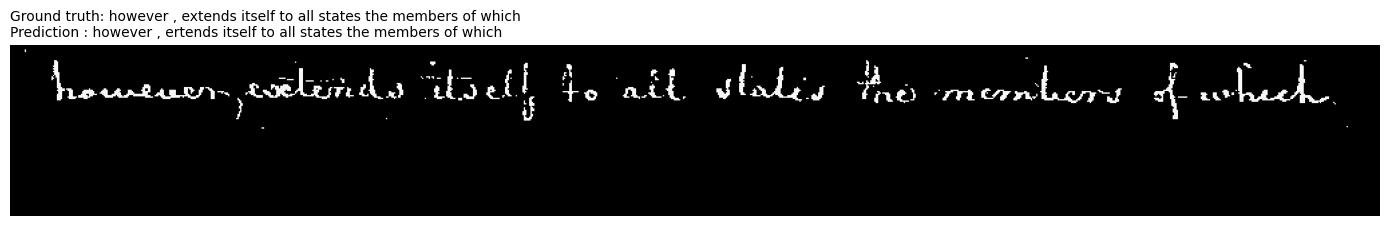

Ground truth: however , extends itself to all states the members of which
Prediction : however , ertends itself to all states the members of which




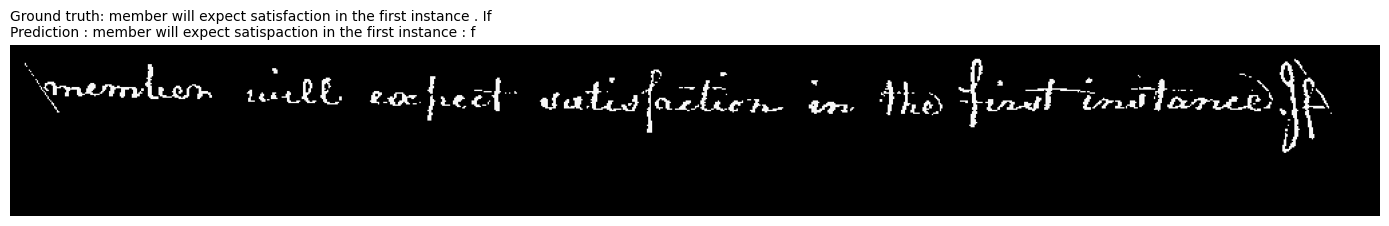

Ground truth: member will expect satisfaction in the first instance . If
Prediction : member will expect satispaction in the first instance : f




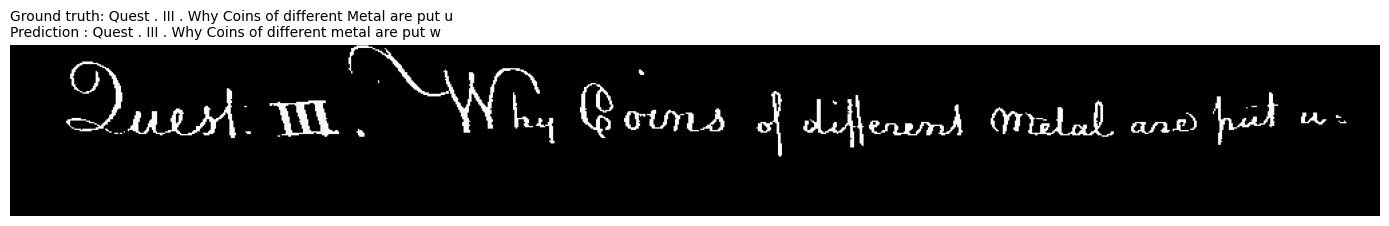

Ground truth: Quest . III . Why Coins of different Metal are put u
Prediction : Quest . III . Why Coins of different metal are put w




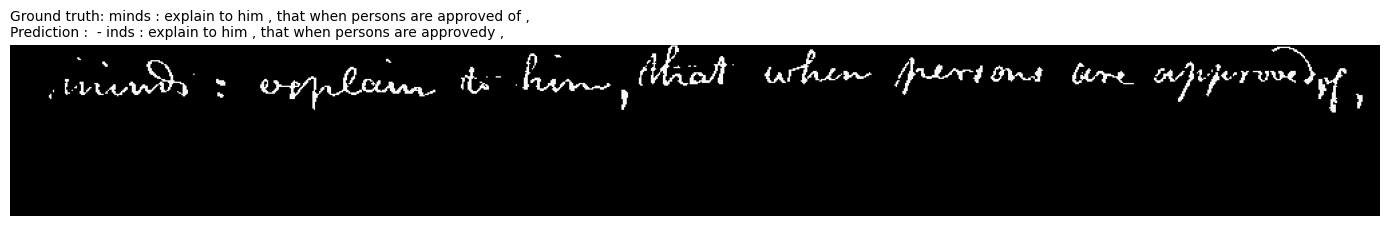

Ground truth: minds : explain to him , that when persons are approved of , 
Prediction :  - inds : explain to him , that when persons are approvedy , 




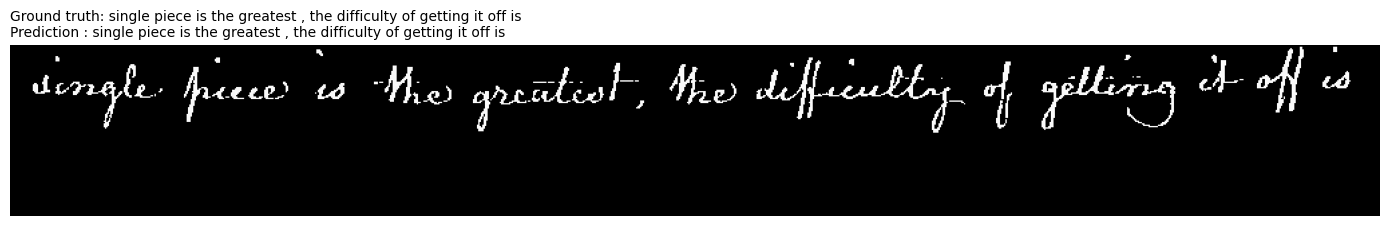

Ground truth: single piece is the greatest , the difficulty of getting it off is
Prediction : single piece is the greatest , the difficulty of getting it off is




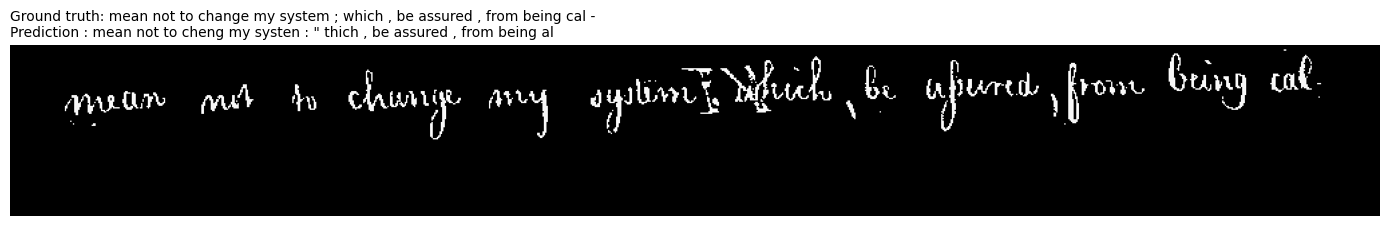

Ground truth: mean not to change my system ; which , be assured , from being cal - 
Prediction : mean not to cheng my systen : " thich , be assured , from being al




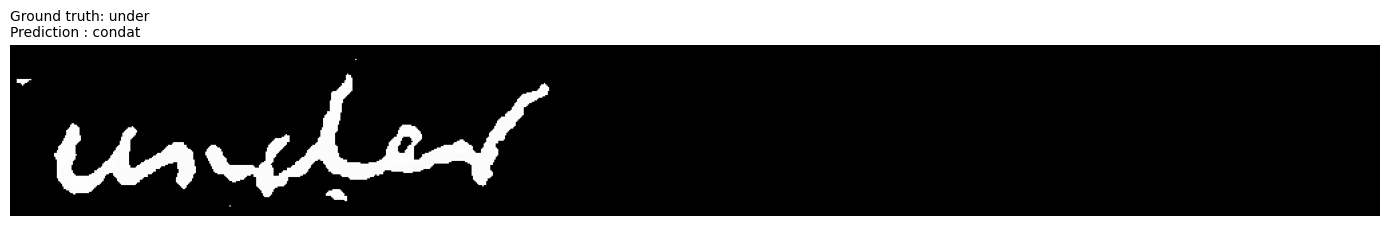

Ground truth: under
Prediction : condat




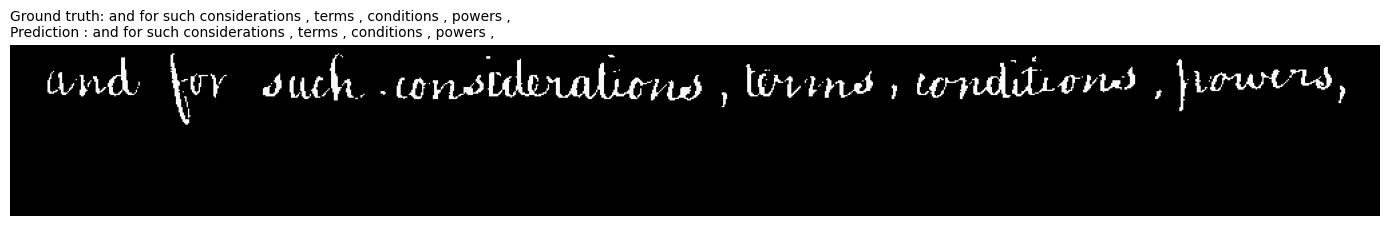

Ground truth: and for such considerations , terms , conditions , powers , 
Prediction : and for such considerations , terms , conditions , powers , 




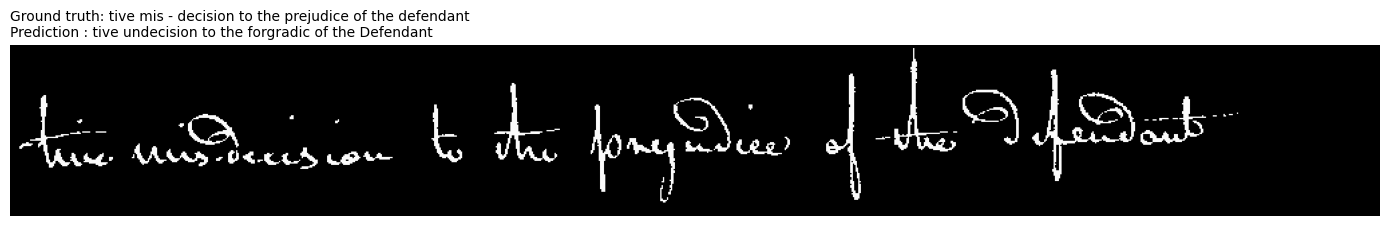

Ground truth: tive mis - decision to the prejudice of the defendant
Prediction : tive undecision to the forgradic of the Defendant




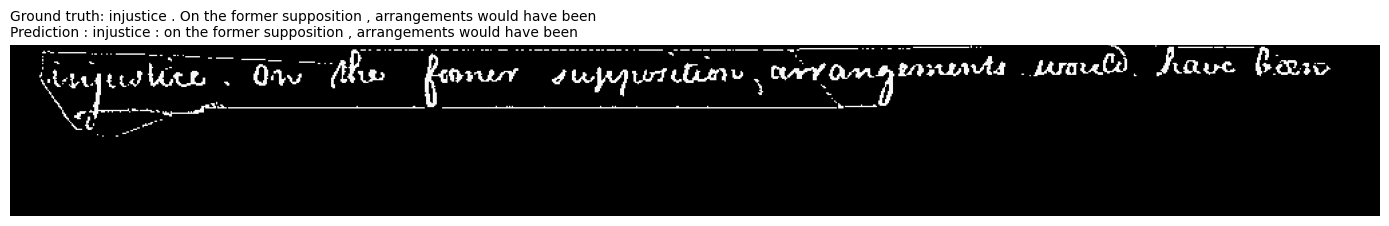

Ground truth: injustice . On the former supposition , arrangements would have been
Prediction : injustice : on the former supposition , arrangements would have been



In [19]:
i = 20
for i, item in enumerate(imgs[i:i+10] , start = i):
    print("=" * 80, "\n")
    img = item.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_display = adjust_to_see(img)
    plt.figure(figsize=(14, 3))
    plt.imshow(img_display, cmap='gray')
    plt.axis('off')
    plt.title(f"Ground truth: {gt[i]}\nPrediction : {predicts[i]}", fontsize=10, loc='left')
    plt.tight_layout()
    plt.show()
    print(f"Ground truth: {gt[i]}")
    print(f"Prediction : {predicts[i]}\n")